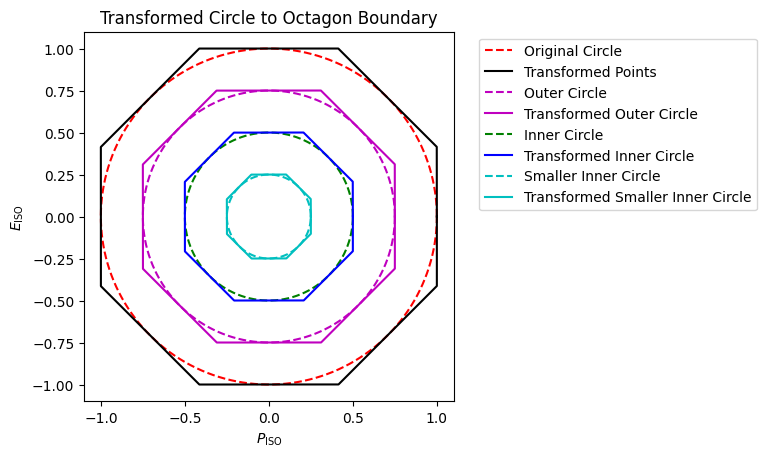

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

def ray_polygon_intersection(direction, polygon):
    dx, dy = direction
    t_min = np.inf
    
    for i in range(len(polygon)):
        p1 = polygon[i]
        p2 = polygon[(i + 1) % len(polygon)]
        
        edge = p2 - p1
        A = np.array([[dx, -edge[0]],
                      [dy, -edge[1]]])
        
        if abs(np.linalg.det(A)) < 1e-12:
            continue
        
        t, u = np.linalg.solve(A, p1)
        
        if t > 0 and 0 <= u <= 1:
            t_min = min(t_min, t)
    
    return t_min


def iso_transform(x, y):
    r = np.hypot(x, y)
    
    if r == 0:
        return 0.0, 0.0

    direction = np.array([x, y])
    direction = direction / r
    
    # Define the ISO octagon vertices
    a = 1.0
    b = np.sqrt(2) - 1.0

    octagon = np.array([
        [-a, -b],
        [-b, -a],
        [ b, -a],
        [ a, -b],
        [ a,  b],
        [ b,  a],
        [-b,  a],
        [-a,  b]
    ])

    t_boundary = ray_polygon_intersection(direction, octagon)
    
    return t_boundary*x, t_boundary*y


# generate a circle of points at radius 1
angles = np.linspace(0, 2*np.pi, 10000)
circle_points = np.array([[np.cos(a), np.sin(a)] for a in angles])
transformed_points = np.array([iso_transform(x, y) for x, y in circle_points])

# generate an outer circle of points at radius 0.75
outer_circle_points = np.array([[0.75 * np.cos(a), 0.75 * np.sin(a)] for a in angles])
transformed_outer_points = np.array([iso_transform(x, y) for x, y in outer_circle_points])

# generate an inner circle of points at radius 0.5
inner_circle_points = np.array([[0.5 * np.cos(a), 0.5 * np.sin(a)] for a in angles])
transformed_inner_points = np.array([iso_transform(x, y) for x, y in inner_circle_points])

# generate a smaller inner circle of points at radius 0.25
smaller_inner_circle_points = np.array([[0.25 * np.cos(a), 0.25 * np.sin(a)] for a in angles])
transformed_smaller_inner_points = np.array([iso_transform(x, y) for x, y in smaller_inner_circle_points])

# Plot
plt.figure()
plt.plot(circle_points[:, 0], circle_points[:, 1], 'r--', label='Original Circle')
plt.plot(transformed_points[:, 0], transformed_points[:, 1], 'k-', label='Transformed Points')
plt.plot(outer_circle_points[:, 0], outer_circle_points[:, 1], 'm--', label='Outer Circle')
plt.plot(transformed_outer_points[:, 0], transformed_outer_points[:, 1], 'm-', label='Transformed Outer Circle')
plt.plot(inner_circle_points[:, 0], inner_circle_points[:, 1], 'g--', label='Inner Circle')
plt.plot(transformed_inner_points[:, 0], transformed_inner_points[:, 1], 'b-', label='Transformed Inner Circle')
plt.plot(smaller_inner_circle_points[:, 0], smaller_inner_circle_points[:, 1], 'c--', label='Smaller Inner Circle')
plt.plot(transformed_smaller_inner_points[:, 0], transformed_smaller_inner_points[:, 1], 'c-', label='Transformed Smaller Inner Circle')
plt.gca().set_aspect('equal')
plt.title("Transformed Circle to Octagon Boundary")
plt.xlabel("$P_\mathrm{ISO}$")
plt.ylabel("$E_\mathrm{ISO}$")
# place legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



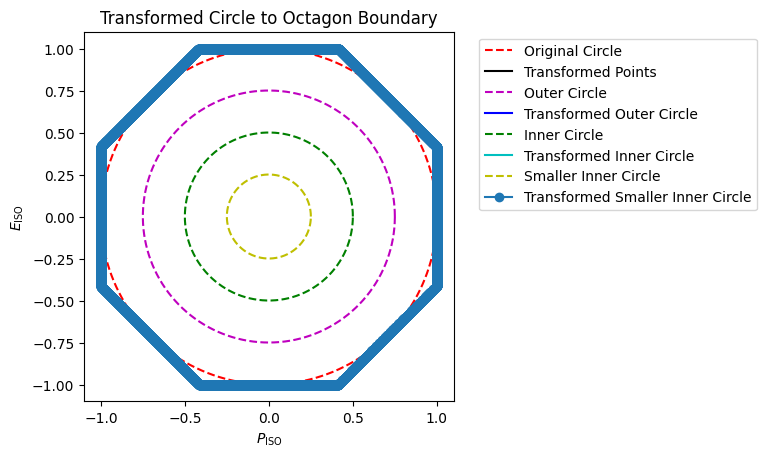

In [36]:
import numpy as np

a = 1.0
b = np.sqrt(2) - 1.0

octagon = np.array([
    [-a, -b],
    [-b, -a],
    [ b, -a],
    [ a, -b],
    [ a,  b],
    [ b,  a],
    [-b,  a],
    [-a,  b]
])


def ray_polygon_intersection_batch(directions, polygon):
    """
    directions: (N, 2) unit vectors
    polygon: (M, 2)
    returns: (N,) intersection distances
    """
    N = directions.shape[0]
    t_min = np.full(N, np.inf)

    for i in range(len(polygon)):
        p1 = polygon[i]
        p2 = polygon[(i + 1) % len(polygon)]
        edge = p2 - p1

        # Build system for all points
        A = np.stack([
            np.stack([directions[:, 0], -edge[0]*np.ones(N)], axis=1),
            np.stack([directions[:, 1], -edge[1]*np.ones(N)], axis=1)
        ], axis=1)  # shape (N, 2, 2)

        det = A[:,0,0]*A[:,1,1] - A[:,0,1]*A[:,1,0]

        valid = np.abs(det) > 1e-12
        if not np.any(valid):
            continue

        A_valid = A[valid]
        p1_tile = np.tile(p1, (np.sum(valid), 1))

        # Solve manually (faster than np.linalg.solve in batch)
        t = (p1_tile[:,0]*A_valid[:,1,1] - p1_tile[:,1]*A_valid[:,0,1]) / det[valid]
        u = (A_valid[:,0,0]*p1_tile[:,1] - A_valid[:,1,0]*p1_tile[:,0]) / det[valid]

        good = (t > 0) & (u >= 0) & (u <= 1)

        idx = np.where(valid)[0][good]
        t_min[idx] = np.minimum(t_min[idx], t[good])

    return t_min


def iso_transform_batch(points):
    """
    points: (N, 2)
    returns: (N, 2)
    """
    r = np.linalg.norm(points, axis=1)
    
    # Avoid divide-by-zero
    nonzero = r > 0
    
    directions = np.zeros_like(points)
    directions[nonzero] = points[nonzero] / r[nonzero][:, None]

    t_boundary = ray_polygon_intersection_batch(directions, octagon)

    transformed = np.zeros_like(points)
    transformed[nonzero] = (t_boundary[nonzero] / r[nonzero])[:, None] * points[nonzero]

    return transformed


# generate a circle of points at radius 1
angles = np.linspace(0, 2*np.pi, 10000)
circle_points = np.array([[np.cos(a), np.sin(a)] for a in angles])
transformed_points = iso_transform_batch(circle_points)

# generate an outer circle of points at radius 0.75
outer_circle_points = np.array([[0.75 * np.cos(a), 0.75 * np.sin(a)] for a in angles])
transformed_outer_points = iso_transform_batch(outer_circle_points)

# generate an inner circle of points at radius 0.5
inner_circle_points = np.array([[0.5 * np.cos(a), 0.5 * np.sin(a)] for a in angles])
transformed_inner_points = iso_transform_batch(inner_circle_points)

# generate a smaller inner circle of points at radius 0.25
smaller_inner_circle_points = np.array([[0.25 * np.cos(a), 0.25 * np.sin(a)] for a in angles])
transformed_smaller_inner_points = iso_transform_batch(smaller_inner_circle_points)

# Plot
plt.figure()
plt.plot(circle_points[:, 0], circle_points[:, 1], 'r--', label='Original Circle')
plt.plot(transformed_points[:, 0], transformed_points[:, 1], 'k-', label='Transformed Points')
plt.plot(outer_circle_points[:, 0], outer_circle_points[:, 1], 'm--', label='Outer Circle')
plt.plot(transformed_outer_points[:, 0], transformed_outer_points[:, 1], 'b-', label='Transformed Outer Circle')
plt.plot(inner_circle_points[:, 0], inner_circle_points[:, 1], 'g--', label='Inner Circle')
plt.plot(transformed_inner_points[:, 0], transformed_inner_points[:, 1], 'c-', label='Transformed Inner Circle')
plt.plot(smaller_inner_circle_points[:, 0], smaller_inner_circle_points[:, 1], 'y--', label='Smaller Inner Circle')
plt.plot(transformed_smaller_inner_points[:, 0], transformed_smaller_inner_points[:, 1], 'o-', label='Transformed Smaller Inner Circle')
plt.gca().set_aspect('equal')
plt.title("Transformed Circle to Octagon Boundary")
plt.xlabel("$P_\mathrm{ISO}$")
plt.ylabel("$E_\mathrm{ISO}$")
# place legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()